# SILVA Consistency DEQ

This lab derives solver-time consistency distillation, constructs an exact
contractive teacher, trains the refiner, and measures the one/few-step tradeoff.
The mechanism follows Consistency Deep Equilibrium Models [[59]](https://jseluis.github.io/silva-networks/paper/references/#ref-59); the teacher,
student, solver, time map, and readout remain replaceable SILVA components.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[59]](https://jseluis.github.io/silva-networks/paper/references/#ref-59), [[65]](https://jseluis.github.io/silva-networks/paper/references/#ref-65), [[66]](https://jseluis.github.io/silva-networks/paper/references/#ref-66), [[67]](https://jseluis.github.io/silva-networks/paper/references/#ref-67). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(33)

from torch import nn
from silva_networks import (
    SILVAConsistencyDEQ,
    SolverConfig,
    make_consistency_teacher_dataset,
    silva_consistency_loss,
)

## 1. Teacher Equilibrium and Solver-Time Path

For a SILVA transition $f_\theta$,

$$z^\star=f_\theta(z^\star,x),\qquad F_\theta(z;x)=f_\theta(z,x)-z=0.$$

Fixing $z_0$ and the solver selects one trajectory $\{z_k\}_{k=0}^{K}$.
The compact teacher is affine, so its exact equilibrium is

$$z^\star=(I-A)^{-1}(Bx+b).$$

In [3]:
data = make_consistency_teacher_dataset(
    samples=48, state_dim=6, condition_dim=4, seed=33
)

class AffineTeacher(nn.Module):
    def __init__(self, matrix, source, bias):
        super().__init__()
        self.register_buffer("matrix", matrix)
        self.register_buffer("source", source)
        self.register_buffer("bias", bias)

    def forward(self, state, condition):
        return state @ self.matrix.T + condition @ self.source.T + self.bias

teacher = AffineTeacher(data.matrix, data.source_matrix, data.bias)
model = SILVAConsistencyDEQ(
    6,
    4,
    teacher_transition=teacher,
    teacher_config=SolverConfig(
        solver="anderson", max_iter=14, tol=1e-7, anderson_batch_dims=1
    ),
)
trajectory = model.teacher_trajectory(data.condition)
teacher_error = torch.linalg.vector_norm(
    trajectory.equilibrium - data.equilibrium, dim=-1
).max()
assert teacher_error < 3e-5
print("teacher states:", len(trajectory.states))
print("maximum exact-equilibrium error:", float(teacher_error))
print("terminal solver residual:", trajectory.solver_result.residual)

teacher states: 16
maximum exact-equilibrium error: 3.992680888131872e-07
terminal solver residual: 1.6755733440732001e-06


## 2. Terminally Anchored Consistency Map

$$
g_\phi(z_t,t,x)=c_{\rm skip}(t)z_t+c_{\rm out}(t)P_\phi(z_{\leq t},t,x),
$$

$$
c_{\rm skip}(t)=\left(\frac{t-\epsilon}{T-\epsilon}\right)^\gamma,
\quad c_{\rm out}(t)=1-c_{\rm skip}(t),
\quad t_k=\epsilon+(1-e^{-\rho k})(T-\epsilon).
$$

At $T$, the map is the identity on the teacher endpoint. Earlier times permit
large learned corrections. A two-state history activates the
Anderson-structured proposal.

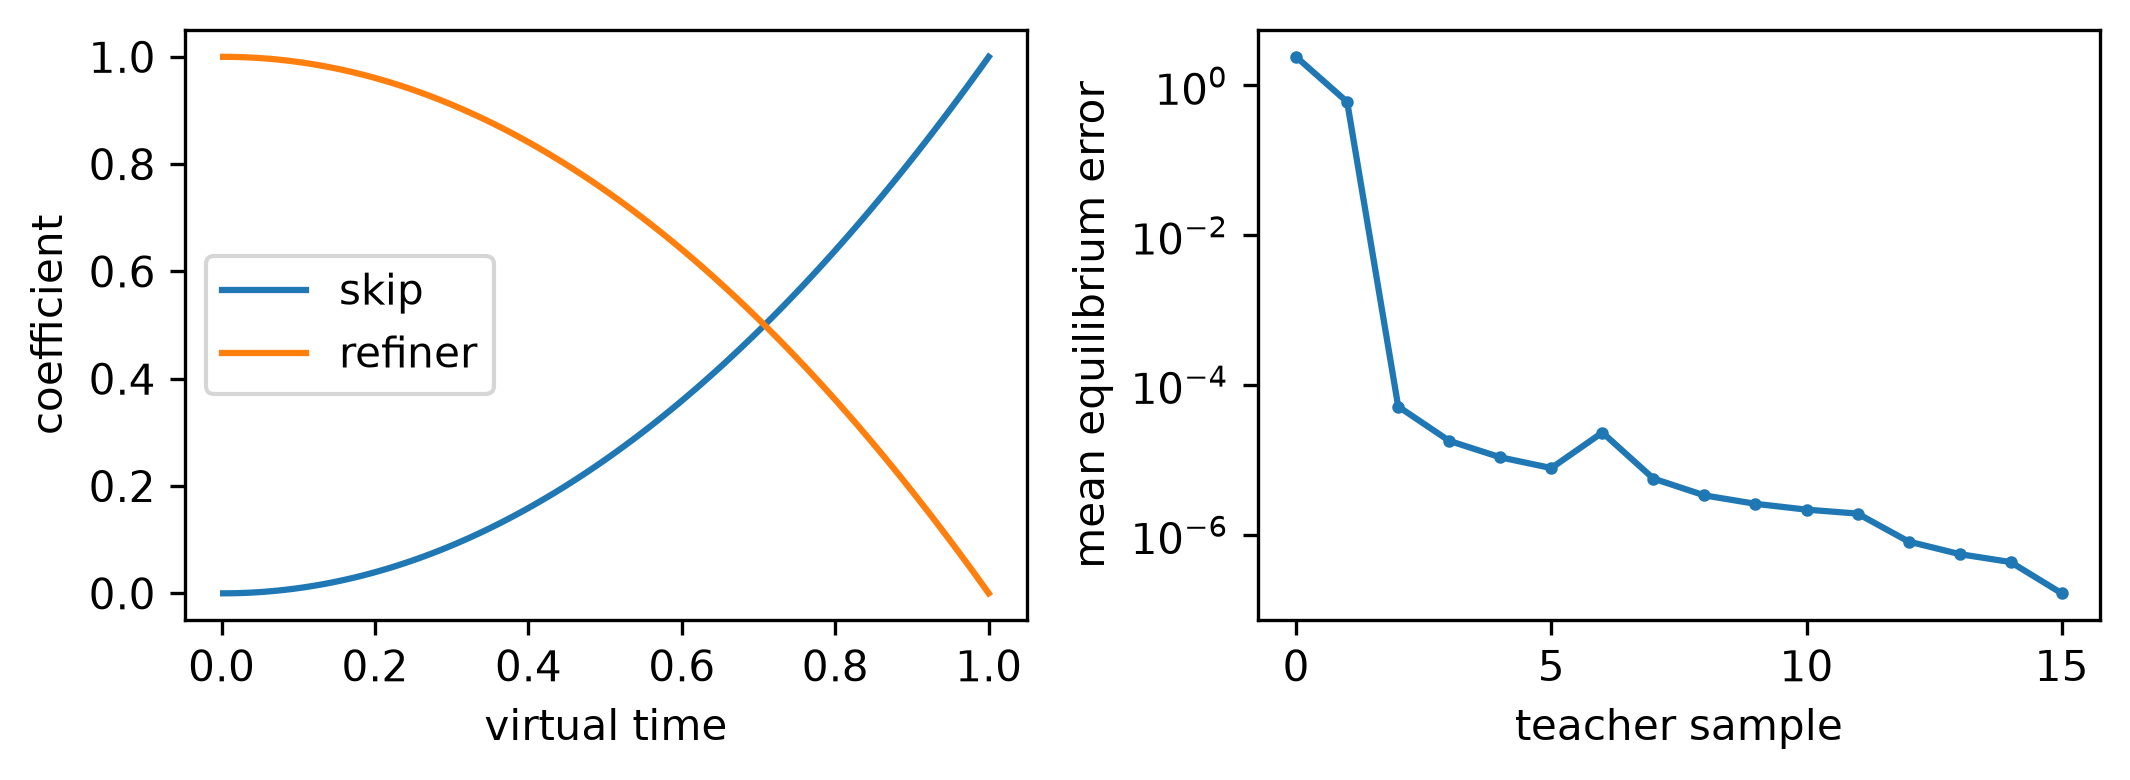

In [4]:
times = torch.linspace(model.epsilon, model.terminal_time, 100)
skip, out = model.boundary_coefficients(times)
figure, axes = plt.subplots(1, 2, figsize=(7.2, 2.7))
axes[0].plot(times, skip, label="skip")
axes[0].plot(times, out, label="refiner")
axes[0].set(xlabel="virtual time", ylabel="coefficient")
axes[0].legend()

solver_errors = [
    float(torch.linalg.vector_norm(state - data.equilibrium, dim=-1).mean())
    for state in trajectory.states
]
axes[1].semilogy(solver_errors, marker="o", markersize=2)
axes[1].set(xlabel="teacher sample", ylabel="mean equilibrium error")
figure.tight_layout()
plt.show()

## 3. Global and Local Distillation

Global consistency maps every sampled state to $z_K$. Local consistency makes
adjacent states agree under the current and exponential-moving-average models:

$$
\mathcal L=\lambda d(g_\phi(z_k),z_K)
+(1-\lambda)d(g_\phi(z_k),g_{\phi^-}(z_{k-1})).
$$

The compact optimization below uses the global term to isolate terminal
matching. The API also accepts the adjacent prediction and task loss.

In [5]:
optimizer = torch.optim.Adam(model.refiner.parameters(), lr=2e-2)
losses = []
for _ in range(80):
    optimizer.zero_grad()
    prediction = model(data.condition, steps=1, return_result=True)
    objective = silva_consistency_loss(
        prediction.state, trajectory.equilibrium, global_weight=1.0
    )
    objective.total.backward()
    optimizer.step()
    losses.append(float(objective.total.detach()))

errors = {}
for steps in (1, 2, 4):
    value = model(data.condition, steps=steps)
    errors[steps] = float(
        torch.linalg.vector_norm(value - trajectory.equilibrium, dim=-1).mean()
    )
print("initial/final distillation loss:", losses[0], losses[-1])
print("mean equilibrium error by evaluations:", errors)

initial/final distillation loss: 1.1735422611236572 0.0015551766846328974
mean equilibrium error by evaluations: {1: 0.0887269601225853, 2: 0.6969709396362305, 4: 0.8981372714042664}


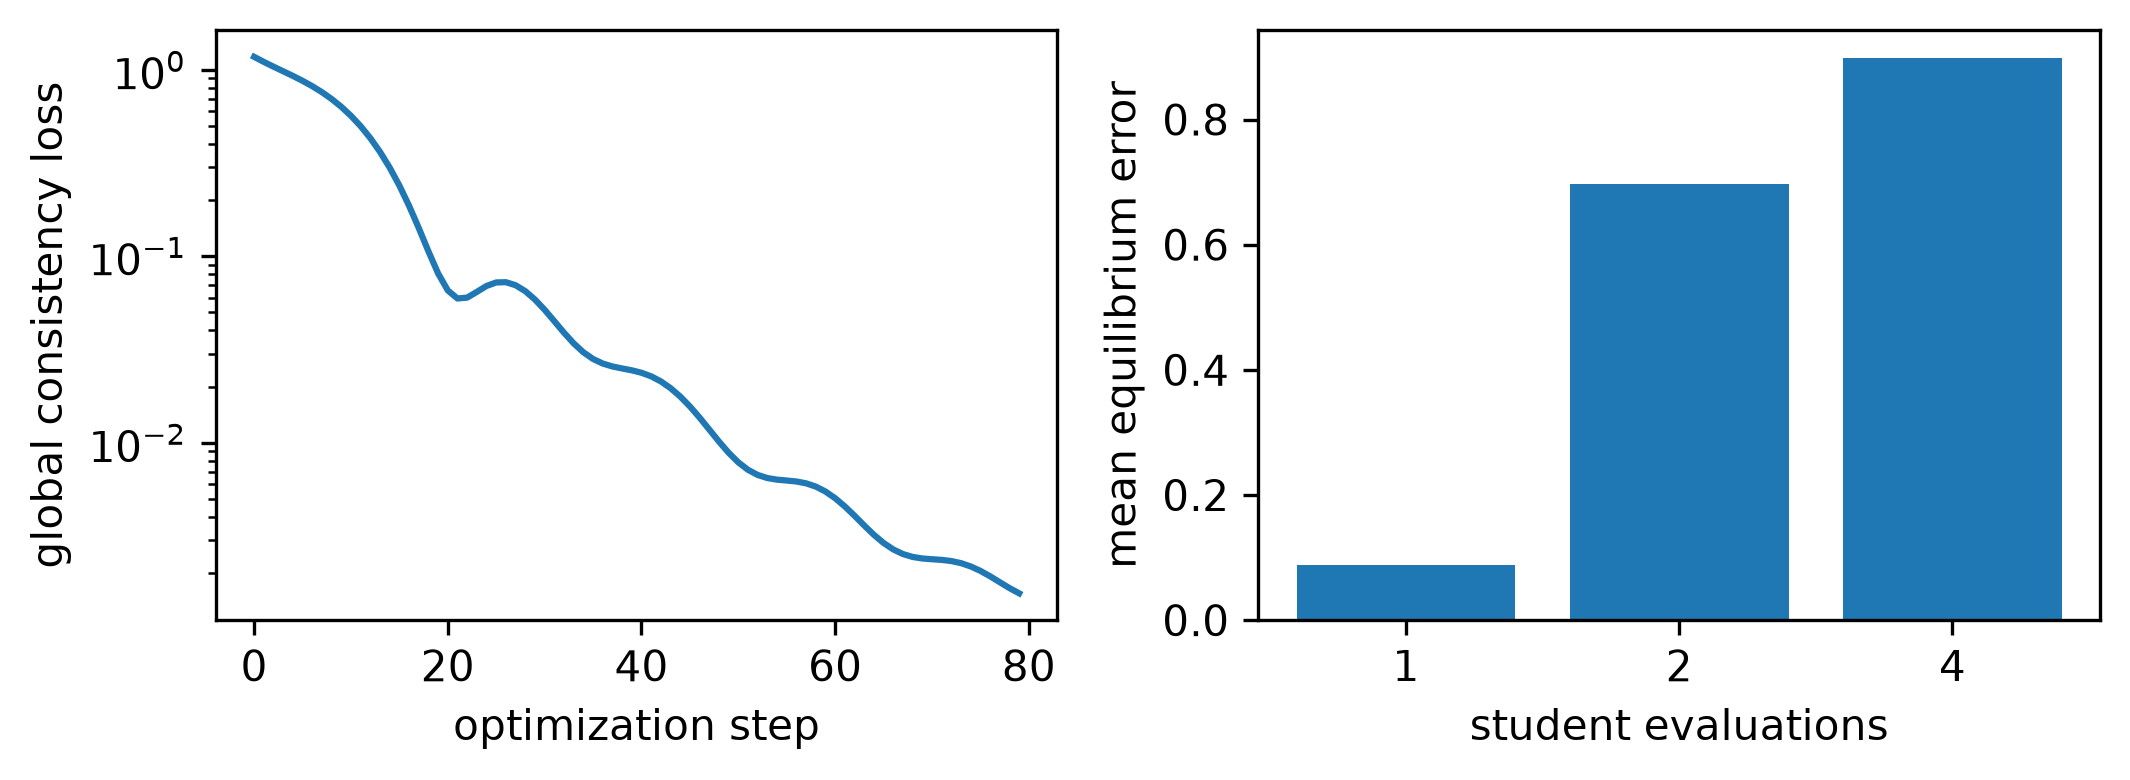

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 2.7))
axes[0].semilogy(losses)
axes[0].set(xlabel="optimization step", ylabel="global consistency loss")
axes[1].bar([str(key) for key in errors], list(errors.values()))
axes[1].set(xlabel="student evaluations", ylabel="mean equilibrium error")
figure.tight_layout()
plt.show()

## 4. Scaling and Reproduction

For a source task, first train or obtain the teacher, then cache solver states
with the exact initial state and solver. Cache size is

$$N_{samples}\,N_{stored}\,N_{state}\,N_{bytes}.$$

Use the source tokenization or image/graph preprocessing, train local and global
terms with an EMA target, and report task quality against network evaluations,
latency, and teacher-equilibrium error. WikiText-103, ImageNet, ogbn-arxiv, and
ogbn-products require their own task heads and data loaders; the consistency
module itself does not change.

## Source Data and Full Experiment Preflight

The reference route provides WikiText-103 [[65]](https://jseluis.github.io/silva-networks/paper/references/#ref-65), OGB node tasks [[66]](https://jseluis.github.io/silva-networks/paper/references/#ref-66), and registered ImageNet access [[67]](https://jseluis.github.io/silva-networks/paper/references/#ref-67). Use 512-2,048 examples and a small deterministic trajectory cache before producing the complete teacher-state archive.

The executable record below distinguishes public, generated, and licensed
inputs and keeps storage and launch steps next to the model contract. Compact
results validate the implementation route; the cited benchmark additionally
requires every recorded source-scale step.

In [7]:
from silva_networks import silva_reproduction_spec

source_plan = silva_reproduction_spec('silva_consistency_deq')
print("data sources:")
for source in source_plan.data_sources:
    print(" -", source)
print("access:")
for item in source_plan.data_access:
    print(" -", item)
print("storage:")
for item in source_plan.storage_plan:
    print(" -", item)
print("source-scale steps:")
for index, item in enumerate(source_plan.source_scale_steps, start=1):
    print(f" {index}. {item}")

data sources:
 - https://github.com/landrarwolf/CDEQ
 - https://www.salesforce.com/blog/the-wikitext-long-term-dependency-language-modeling-dataset/
 - https://ogb.stanford.edu/docs/nodeprop/
 - https://www.image-net.org/
access:
 - WikiText-103 and OGB provide public acquisition routes under their stated terms.
 - ImageNet requires registration and acceptance of its access terms.
 - Record the teacher and consistency-checkpoint revisions separately from the dataset checksum.
storage:
 - Teacher cache bytes = samples * stored solver states * state elements * bytes per element.
 - For example, 1,000,000 vector samples with 8 stored 512-float32 states require about 15.3 GiB before labels, indices, and checkpoints.
source-scale steps:
 1. Acquire one official task and reproduce its teacher preprocessing and evaluation first.
 2. Load the teacher checkpoint into the matching SILVA transition and cache deterministic solver trajectories.
 3. Train the refiner with global/local consistency an

## From 28 Silva Consistency Deq to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the latent vector or tensor z |
| Condition | the injected observation x |
| Repeated computation | the tied map f_theta(z, x) |
| Required invariants | state shape and a decreasing or bounded residual |
| Replaceable components | transition, damping, stopping rule, backward solver, and readout |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Teacher and Few-Step Refiner

```python
model = SILVAConsistencyDEQ(
    teacher_transition=my_equilibrium_transition,
    condition_dim=condition_dim,
    state_dim=state_dim,
    initializer=my_state_initializer,
    refiner=my_terminally_anchored_refiner,
    time_schedule=my_solver_time_schedule,
    teacher_config=teacher_solver_config,
)
```

The teacher transition defines the target fixed point. The refiner implements
`refiner(state_at_time, virtual_time, condition)` and may be distilled with
global, local, or combined consistency objectives. Full runs should preserve
the teacher checkpoints, time discretization, EMA policy, and one- and two-step
evaluation protocols independently.


In [8]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**distance to an analytic fixed point and final relative residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **latent width, solver tolerance, and iteration budget**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [9]:
notebook_reproduction_record = {
    "notebook": '28_silva_consistency_deq.ipynb',
    "state": 'the latent vector or tensor z',
    "condition": 'the injected observation x',
    "transition": 'the tied map f_theta(z, x)',
    "invariants": 'state shape and a decreasing or bounded residual',
    "compact_metric": 'distance to an analytic fixed point and final relative residual',
    "scale_axis": 'latent width, solver tolerance, and iteration budget',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '28_silva_consistency_deq.ipynb',
 'state': 'the latent vector or tensor z',
 'condition': 'the injected observation x',
 'transition': 'the tied map f_theta(z, x)',
 'invariants': 'state shape and a decreasing or bounded residual',
 'compact_metric': 'distance to an analytic fixed point and final relative residual',
 'scale_axis': 'latent width, solver tolerance, and iteration budget'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the latent vector or tensor z**, and its repeated map,
**the tied map f_theta(z, x)**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [10]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


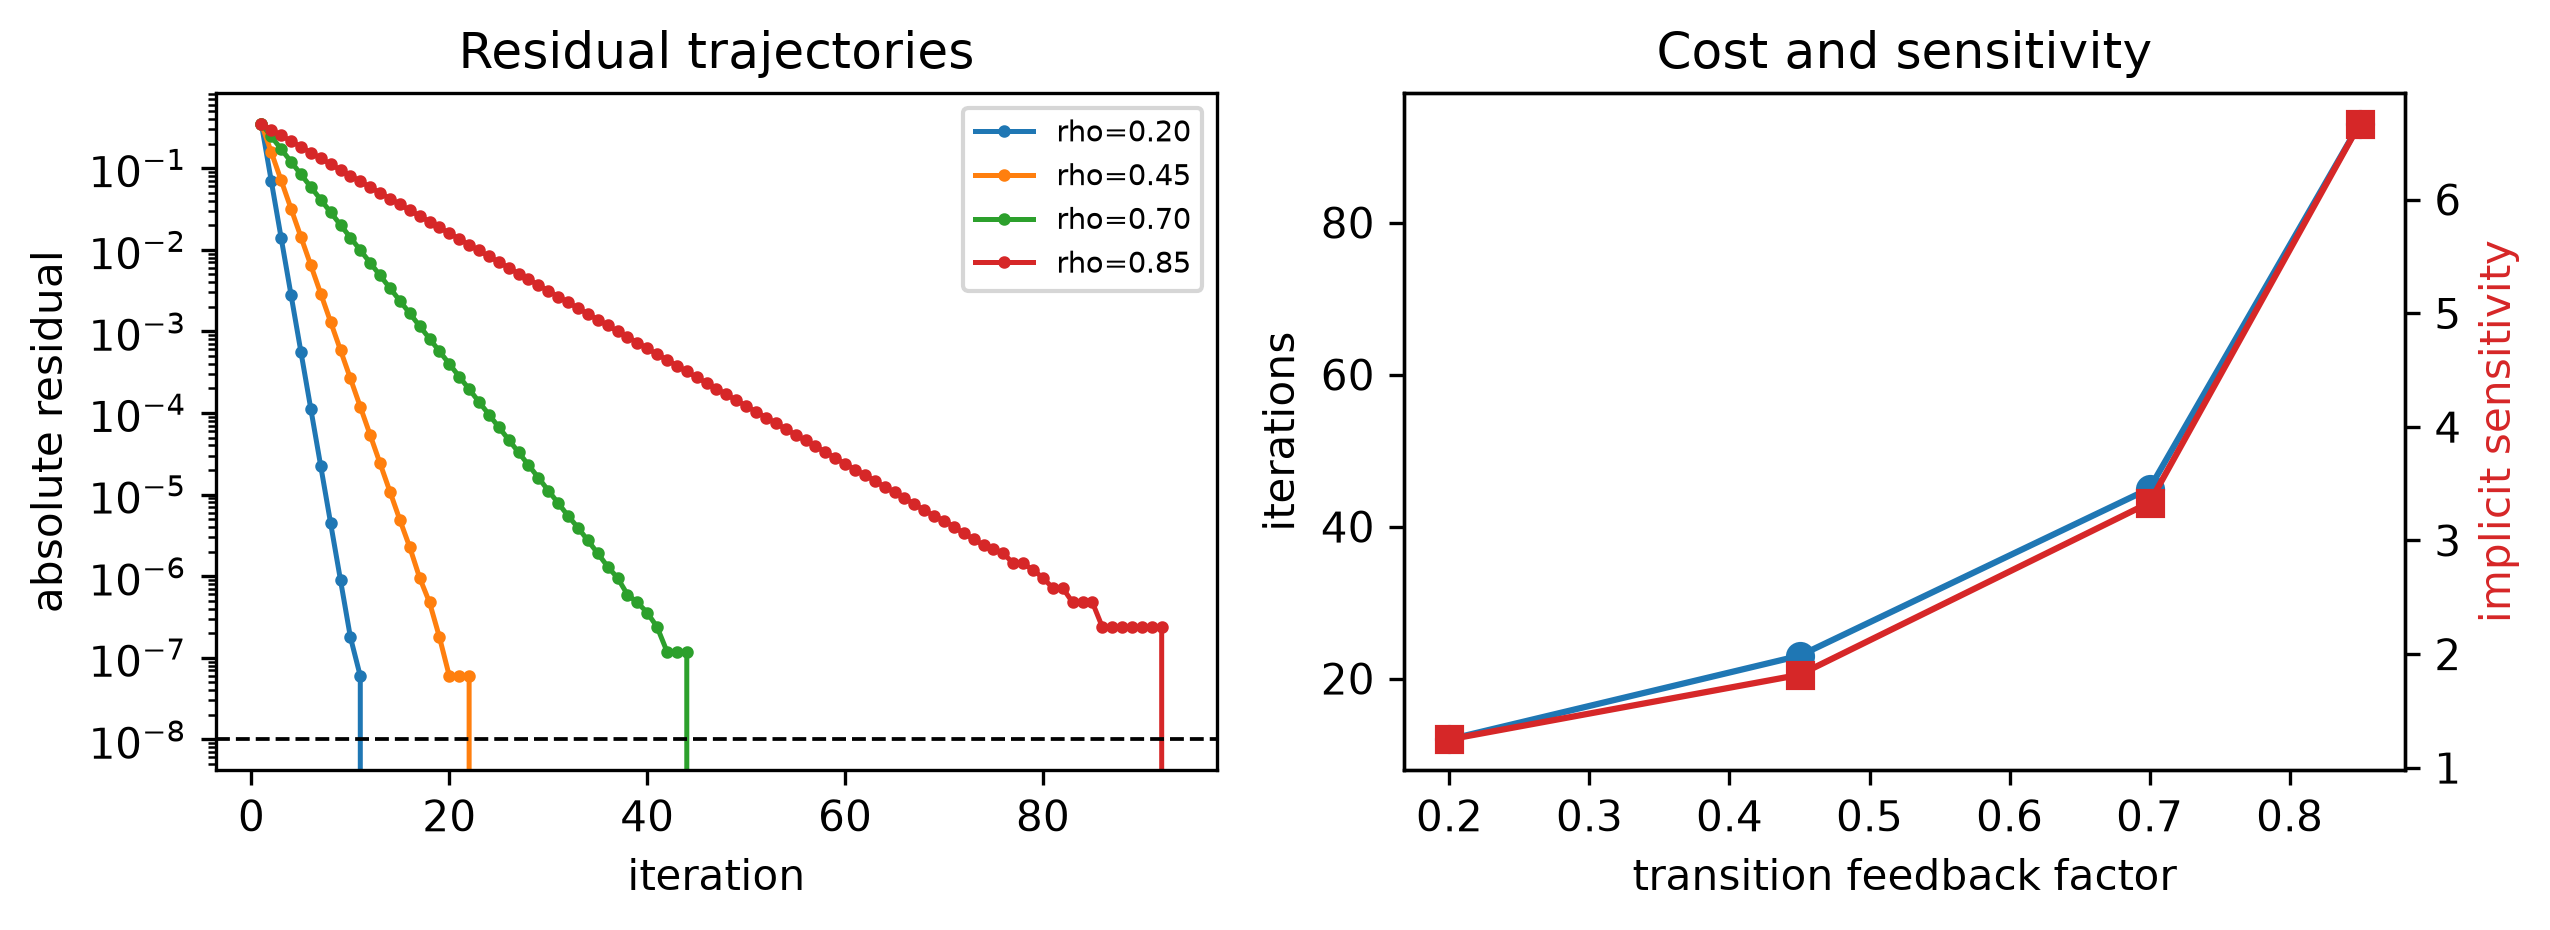

In [11]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | distance to an analytic fixed point and final relative residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | state shape and a decreasing or bounded residual |
| Scale sweep | Change one of latent width, solver tolerance, and iteration budget at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is the solver trajectory distilled into one or two steps? | [Emerging Equilibrium Methods](https://jseluis.github.io/silva-networks/learn/emerging-equilibrium-methods/#consistency-deq) |
| Which consistency modules and losses are public? | [Emerging Equilibria API](https://jseluis.github.io/silva-networks/api/emerging_equilibria/) |
| How is a full source experiment specified? | [Reproducing SILVA and Source Methods](https://jseluis.github.io/silva-networks/learn/reproducing-silva-and-papers/) |
